# 02 — Advanced feature engineering

**Estimated time:** 120–150 minutes  
**Prerequisites:** notebooks 00–01; gradient boosting, pipelines, cross-validation, and metrics.  
**Depends on:** the pre-contact feature contract.

## Learning objectives

- Build robust, leakage-safe transformations for mixed tabular data.
- Handle sentinels, rare/unseen categories, ratios, bins, and nonlinear structure.
- Compare one-hot encoding with CatBoost native categorical handling.
- Use fold-level uncertainty and family-wise ablation to judge feature value.
- Inspect the transformed feature space and connect features to model behavior.

## CatBoost in one minute

**CatBoost** means *Categorical Boosting*. It is a gradient-boosted decision-tree library whose
categorical-feature processing is part of model training rather than a separate preprocessing
step. That matters here because fields such as `job`, `month`, `contact`, and `poutcome` are
categories, not quantities with a meaningful numeric order.

### 1. Start with gradient boosting

A single shallow decision tree captures only a small part of the pattern. Gradient boosting builds
an ensemble sequentially:

1. begin with a simple constant prediction;
2. measure each row's error under the chosen loss function;
3. fit a new tree that reduces those errors;
4. add the new tree's contribution, scaled by the learning rate;
5. repeat for many iterations.

For binary classification, the ensemble produces a raw score that is converted to a probability.
Parameters in this notebook control the process: `iterations` is the maximum number of trees,
`depth` limits tree complexity, `learning_rate` controls the size of each correction, and
`loss_function="Logloss"` defines what training tries to minimize.

### 2. Why naive categorical encoding is risky

One-hot encoding creates one column per category. It is simple and works well for low-cardinality
features, but the matrix becomes wide when a feature has many values. A tempting alternative is
target encoding: replace each category with its observed positive rate. If that rate is calculated
using the same row's target, however, the feature contains information about the answer. Rare
categories are especially vulnerable: a category seen once would encode its label almost exactly.

### 3. CatBoost's ordered target statistics

CatBoost randomly permutes the training rows and processes them as if they arrived sequentially.
For a particular row, its category statistic is calculated only from earlier rows in that
permutation. A smoothed prior stabilizes categories with little history.

For example, suppose the current row has `job="admin"`. Its encoded value can use earlier
`admin` rows and their labels, but not the current row's label or labels from later rows. CatBoost
may also construct statistics for useful category combinations. During validation or prediction,
statistics learned from training data are applied without using validation or future targets.

### 4. Ordered statistics and ordered boosting are related but different

- **Ordered target statistics** protect categorical encodings from using a row's own target.
- **Ordered boosting** addresses a second source of prediction shift by calculating training
  residuals with models that have not already learned from the row being evaluated.

Both ideas use permutations, but they solve different leakage-like biases. CatBoost supports
different boosting modes; the essential lesson is not that every configuration always uses the
same mode, but that its categorical statistics are designed to avoid naive full-data target
encoding.

### 5. How a prediction is produced

At inference time, CatBoost receives the raw numeric and categorical columns. It applies the
categorical statistics learned during training, sends the resulting values through every tree,
sums the tree contributions, and converts the final score into a probability. The target is never
required at prediction time. A threshold such as `0.5` then converts the probability into `yes`
or `no`.

### 6. What CatBoost is—and is not—testing here

Logistic regression plus one-hot encoding is our controlled feature-engineering experiment.
CatBoost is a separate workflow benchmark combining a different encoding strategy with a more
flexible nonlinear model. A better CatBoost result therefore does **not** prove that native
categorical encoding alone caused the improvement.

We use an internal development subset for early stopping, recover the selected number of trees,
and refit on all development rows. Only then do we evaluate once on the untouched validation set.
Training is monitored with log loss because it reacts to probability quality; final reporting uses
accuracy, balanced accuracy, precision, recall, and F1 at the fixed `0.5` threshold.


### CatBoost workflow at a glance

![CatBoost workflow: raw mixed features are permuted, converted into leakage-safe ordered category statistics, processed by sequential trees, and converted into a probability and thresholded prediction.](../assets/catboost_workflow.png)

Read the upper path from left to right. The lower inset isolates the central safety idea: naive
target encoding calculates a category rate using every label—including the current row—whereas
ordered statistics use only labels from earlier rows in a permutation. The illustrated numbers
are pedagogical examples, not values calculated from the Bank Marketing dataset.


In [1]:
import hashlib, json, os, platform, random, warnings
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
# Known interoperability/UI warnings do not affect predictions or notebook execution.
warnings.filterwarnings("ignore", message="X does not have valid feature names, but LGBMClassifier")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (balanced_accuracy_score, brier_score_loss, confusion_matrix,
                             f1_score, log_loss, precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
TARGET = "y"
LEAKAGE_COLUMNS = ["duration"]

def project_root():
    '''Return the course root when present, otherwise the notebook directory.'''
    # Return the course root when present, otherwise the notebook's directory.
    return ROOT

def set_seed(seed=SEED):
    '''Seed Python and NumPy RNGs for reproducible notebook runs.'''
    random.seed(seed)
    np.random.seed(seed)

def fast_mode():
    '''Report whether notebooks should use the reduced fast-mode sample.'''
    # Set FAST_MODE=0 for full-size experiments; laptop mode is the default.
    return os.getenv("FAST_MODE", "1").lower() not in {"0", "false", "no"}

def bank_data_path():
    '''Locate the bundled Bank Marketing CSV file.'''
    # The course ships with a local dataset; notebooks never access the network.
    path = project_root() / "data" / "raw" / "bank-full.csv"
    if not path.is_file():
        raise FileNotFoundError(
            f"Expected the bundled Bank Marketing data at {path}. "
            "Run the notebook from the course root or place bank-full.csv there."
        )
    return path

def file_sha256(path):
    '''Compute the SHA-256 digest of a local file.'''
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_bank_data(include_duration=False):
    '''Load the Bank Marketing dataset and drop leakage columns by default.'''
    # Load the data, encode y, and exclude post-call duration by default.
    frame = pd.read_csv(bank_data_path(), sep=";")
    frame[TARGET] = frame[TARGET].map({"no": 0, "yes": 1}).astype("int8")
    if not include_duration:
        frame = frame.drop(columns=LEAKAGE_COLUMNS)
    return frame

def stratified_sample(frame, n, seed=SEED):
    '''Draw a label-preserving sample from a classified dataset.'''
    if n >= len(frame):
        return frame.copy()
    fractions = frame[TARGET].value_counts(normalize=True)
    counts = (fractions * n).round().astype(int)
    counts.iloc[0] += n - counts.sum()
    parts = [group.sample(n=min(counts.loc[label], len(group)),
                          random_state=seed + int(label))
             for label, group in frame.groupby(TARGET)]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

def make_splits(frame=None, reduced=None):
    '''Create deterministic stratified train, validation, and test splits.'''
    # Deterministic stratified 60/20/20 split; test stays sealed until notebook 09.
    from sklearn.model_selection import train_test_split
    frame = load_bank_data() if frame is None else frame
    train_val, test = train_test_split(
        frame, test_size=0.20, stratify=frame[TARGET], random_state=SEED)
    train, validation = train_test_split(
        train_val, test_size=0.25, stratify=train_val[TARGET], random_state=SEED)
    reduced = fast_mode() if reduced is None else reduced
    if reduced:
        train = stratified_sample(train, 12_000)
        validation = stratified_sample(validation, 4_000, SEED + 1)
        test = stratified_sample(test, 4_000, SEED + 2)
    return tuple(part.reset_index(drop=True) for part in (train, validation, test))

def split_xy(frame):
    '''Separate a frame into feature matrix and target vector.'''
    return frame.drop(columns=TARGET), frame[TARGET]

def feature_groups(frame):
    '''Identify numeric and categorical feature columns.'''
    features = frame.drop(columns=[TARGET], errors="ignore")
    categorical = features.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numerical = features.select_dtypes(include=np.number).columns.tolist()
    return numerical, categorical

def make_preprocessor(frame, scale_numeric=True):
    '''Build the preprocessing pipeline for numeric and categorical features.'''
    # Preprocessing is fitted only inside the enclosing training/CV pipeline.
    numerical, categorical = feature_groups(frame)
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                 min_frequency=10, sparse_output=True)),
    ])
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numerical),
        ("categorical", categorical_pipe, categorical),
    ], sparse_threshold=0.3)

def classification_metrics(y_true, probability, threshold=0.5):
    '''Compute ranking and threshold-based classification metrics.'''
    prediction = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {"log_loss": log_loss(y_true, probability),
            "brier_score": brier_score_loss(y_true, probability),
            "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
            "f1": f1_score(y_true, prediction, zero_division=0),
            "precision": precision_score(y_true, prediction, zero_division=0),
            "recall": recall_score(y_true, prediction, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "cost": float(fp + 5 * fn)}

def threshold_table(y_true, probability, thresholds=None):
    '''Evaluate classification metrics across a list of decision thresholds.'''
    thresholds = np.linspace(0.05, 0.80, 76) if thresholds is None else thresholds
    return pd.DataFrame([{"threshold": float(t),
                          **classification_metrics(y_true, probability, float(t))}
                         for t in thresholds])

def add_domain_features(frame):
    '''Create domain-inspired features for the Bank Marketing dataset.'''
    result = frame.copy()
    result["was_previously_contacted"] = (result["pdays"] != -1).astype("int8")
    result["pdays_clean"] = result["pdays"].replace(-1, np.nan)
    result["contact_pressure"] = result["campaign"] / (1 + result["previous"])
    result["balance_per_age"] = result["balance"] / result["age"].clip(lower=18)
    result["age_band"] = pd.cut(result["age"], bins=[0, 29, 39, 49, 59, np.inf],
                                labels=["<30", "30s", "40s", "50s", "60+"]).astype("object")
    return result.drop(columns=["pdays"])

def environment_metadata():
    '''Collect runtime metadata for experiment tracking.'''
    import sklearn
    return {"python": platform.python_version(), "platform": platform.platform(),
            "numpy": np.__version__, "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__}

def write_json(data, path):
    '''Serialize structured data to a JSON file on disk.'''
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")

set_seed(SEED)
FAST_MODE = fast_mode()
CV_FOLDS = 3 if FAST_MODE else 5
BRAND_COLOR = "#2a9d8f"
ACCENT_COLOR = "#e76f51"
sns.set_theme(style="whitegrid", context="notebook", palette=[BRAND_COLOR, ACCENT_COLOR, "#264653", "#f4a261"])
plt.rcParams.update({
    "axes.facecolor": "#fcfcfc",
    "figure.facecolor": "white",
    "axes.edgecolor": "#d9d9d9",
    "grid.color": "#e8e8e8",
    "grid.linewidth": 0.8,
    "axes.titleweight": "bold",
    "axes.labelweight": "medium",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 30)
print({"FAST_MODE": FAST_MODE, "CV_FOLDS": CV_FOLDS, "seed": SEED})


{'FAST_MODE': True, 'CV_FOLDS': 3, 'seed': 42}


In [2]:
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             ConfusionMatrixDisplay)

development, validation, _sealed_test = make_splits(load_bank_data(), reduced=FAST_MODE)
X_dev, y_dev = split_xy(development)
X_val, y_val = split_xy(validation)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
CV_SPLITS = list(cv.split(X_dev, y_dev))


## See ordered target statistics happen row by row

This toy example slows down CatBoost's most unusual step. Imagine that the rows below are one
permutation. Before encoding a row, we calculate its category statistic from only the earlier
rows with the same category. A prior supplies a stable value when little history exists.

The left panel shows labels arriving, the middle compares leakage-safe ordered values with naive
full-data target encoding, and the right shows how much same-category history supports each value.
This illustrates the idea rather than reimplementing every CatBoost detail.


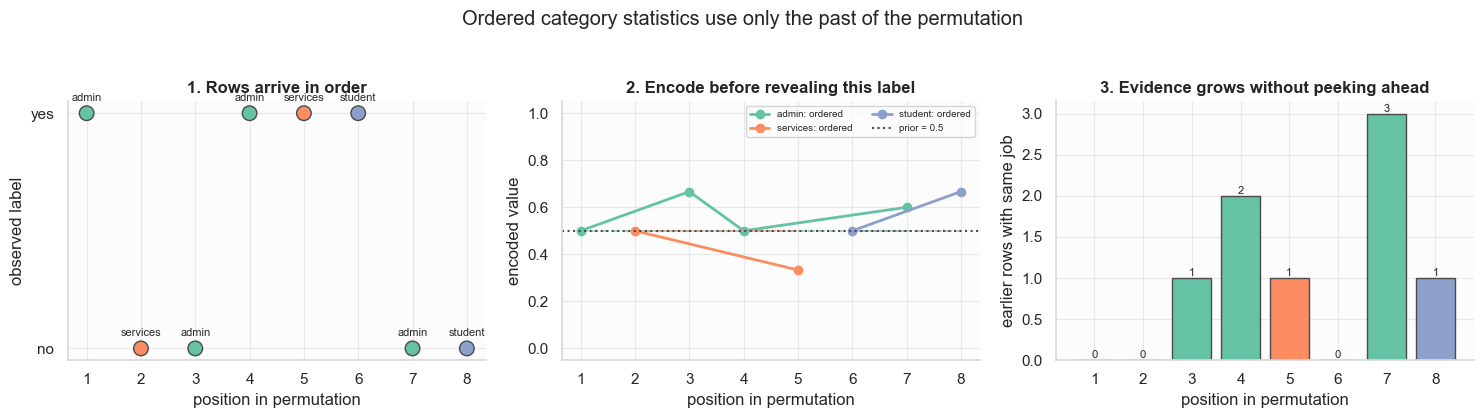

,step,job,subscribed,ordered_stat,earlier_same_job_rows,naive_full_data_stat
0,1,admin,1,0.500,0,0.5
1,2,services,0,0.500,0,0.5
2,3,admin,0,0.667,1,0.5
3,4,admin,1,0.500,2,0.5
4,5,services,1,0.333,1,0.5
5,6,student,1,0.500,0,0.5
6,7,admin,0,0.600,3,0.5
7,8,student,0,0.667,1,0.5


In [3]:
toy_order = pd.DataFrame({
    "step": np.arange(1, 9),
    "job": ["admin", "services", "admin", "admin",
            "services", "student", "admin", "student"],
    "subscribed": [1, 0, 0, 1, 1, 1, 0, 0],
})
prior, prior_weight = 0.5, 2.0
category_sums, category_counts = {}, {}
ordered_values, histories = [], []
for row in toy_order.itertuples(index=False):
    previous_sum = category_sums.get(row.job, 0)
    previous_count = category_counts.get(row.job, 0)
    ordered_values.append(
        (previous_sum + prior_weight * prior) / (previous_count + prior_weight)
    )
    histories.append(previous_count)
    category_sums[row.job] = previous_sum + row.subscribed
    category_counts[row.job] = previous_count + 1

toy_order["ordered_stat"] = ordered_values
toy_order["earlier_same_job_rows"] = histories
toy_order["naive_full_data_stat"] = toy_order.groupby("job")["subscribed"].transform("mean")
job_colors = dict(zip(toy_order["job"].unique(), sns.color_palette("Set2", 3)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(toy_order["step"], toy_order["subscribed"], s=110,
                c=[job_colors[j] for j in toy_order["job"]], edgecolor="#4a4a4a")
for row in toy_order.itertuples(index=False):
    axes[0].annotate(row.job, (row.step, row.subscribed), xytext=(0, 9),
                     textcoords="offset points", ha="center", fontsize=8)
axes[0].set(xticks=toy_order["step"], yticks=[0, 1], yticklabels=["no", "yes"],
            xlabel="position in permutation", ylabel="observed label",
            title="1. Rows arrive in order")

for job, group in toy_order.groupby("job", sort=False):
    axes[1].plot(group["step"], group["ordered_stat"], marker="o", linewidth=2,
                 color=job_colors[job], label=f"{job}: ordered")
    axes[1].plot(group["step"], group["naive_full_data_stat"], linestyle="--",
                 linewidth=1.4, color=job_colors[job], alpha=0.65)
axes[1].axhline(prior, color="#4a4a4a", linestyle=":", label="prior = 0.5")
axes[1].set(xlabel="position in permutation", ylabel="encoded value", ylim=(-0.05, 1.05),
            title="2. Encode before revealing this label")
axes[1].legend(fontsize=7, ncol=2)

bars = axes[2].bar(toy_order["step"], toy_order["earlier_same_job_rows"],
                   color=[job_colors[j] for j in toy_order["job"]], edgecolor="#4a4a4a")
axes[2].bar_label(bars, fontsize=8)
axes[2].set(xticks=toy_order["step"], xlabel="position in permutation",
            ylabel="earlier rows with same job",
            title="3. Evidence grows without peeking ahead")
fig.suptitle("Ordered category statistics use only the past of the permutation", y=1.04)
plt.tight_layout()
plt.show()
display(toy_order.round(3))


## Audit the raw feature space

Feature hypotheses should follow evidence. We first inspect types, cardinality, missingness,
and sentinel values. Here, `pdays=-1` is documented as "not previously contacted," so it is
information rather than ordinary missingness.


In [4]:
feature_audit = pd.DataFrame({
    "dtype": X_dev.dtypes.astype(str),
    "unique": X_dev.nunique(dropna=False),
    "missing_pct": X_dev.isna().mean().mul(100),
}).sort_values(["dtype", "unique"])
display(feature_audit)
display(pd.crosstab(X_dev["pdays"].eq(-1), y_dev, normalize="index")
        .rename(index={True: "never contacted", False: "contacted"}))


,dtype,unique,missing_pct
day,int64,31,0.0
previous,int64,33,0.0
campaign,int64,40,0.0
age,int64,74,0.0
pdays,int64,409,0.0
balance,int64,4077,0.0
default,object,2,0.0
housing,object,2,0.0
loan,object,2,0.0
marital,object,3,0.0


y,0,1
pdays,,
contacted,0.782407,0.217593
never contacted,0.905081,0.094919


## Feature hypotheses before code

- `pdays=-1` mixes a missing-history state with numeric recency. Split it into an indicator and
  nullable recency.
- `campaign / (1 + previous)` approximates current contact pressure relative to known history.
- `balance / age` is a deliberately weak ratio hypothesis, clipped only through the valid age
  denominator; ablation will decide whether it helps.
- Age bins allow nonlinearity but sacrifice local detail.

These are predictive transformations, not causal mechanisms. The transformer is row-wise and
stateless; learned imputation, scaling, and category vocabularies remain inside the pipeline.


In [5]:
REQUIRED_FEATURE_COLUMNS = {"pdays", "campaign", "previous", "balance", "age"}

def add_domain_features(frame):
    """Create pre-contact domain features using row-wise, stateless logic."""
    missing = REQUIRED_FEATURE_COLUMNS.difference(frame.columns)
    if missing:
        raise ValueError(f"missing required columns: {sorted(missing)}")
    if frame["age"].dropna().le(0).any():
        raise ValueError("age must be positive when present")
    if frame["previous"].dropna().lt(0).any():
        raise ValueError("previous must be non-negative when present")
    result = frame.copy()

    # In this dataset, pdays=-1 means the client was never previously contacted.
    result["was_previously_contacted"] = (result["pdays"] != -1).astype("int8")
    result["pdays_clean"] = result["pdays"].replace(-1, np.nan)

    # Hypotheses to validate by ablation rather than assume useful.
    result["contact_pressure"] = result["campaign"] / (1 + result["previous"])
    result["balance_per_age"] = result["balance"] / result["age"].clip(lower=18)
    result["age_band"] = pd.cut(
        result["age"],
        bins=[0, 29, 39, 49, 59, np.inf],
        labels=["<30", "30s", "40s", "50s", "60+"],
    ).astype("object")

    return result.drop(columns=["pdays"])


In [6]:
engineered_preview = add_domain_features(X_dev.head())
engineered_preview.T


,0,1,2,3,4
age,40,56,56,31,30
job,blue-collar,management,admin.,self-employed,management
marital,married,married,divorced,single,single
education,secondary,tertiary,secondary,tertiary,tertiary
default,no,no,no,no,no
balance,271,1282,-429,283,61
housing,yes,no,no,no,yes
loan,no,no,yes,no,no
contact,unknown,cellular,cellular,cellular,telephone
day,29,19,23,28,5


## Visualize the feature-engineering process

Each panel corresponds to one hypothesis in `add_domain_features`: separate the `pdays=-1`
state from genuine recency, normalize campaign effort by contact history, express balance relative
to age, and convert continuous age into broad nonlinear regions. The plots explain what each
transformation does; cross-validation later decides whether it helps prediction.


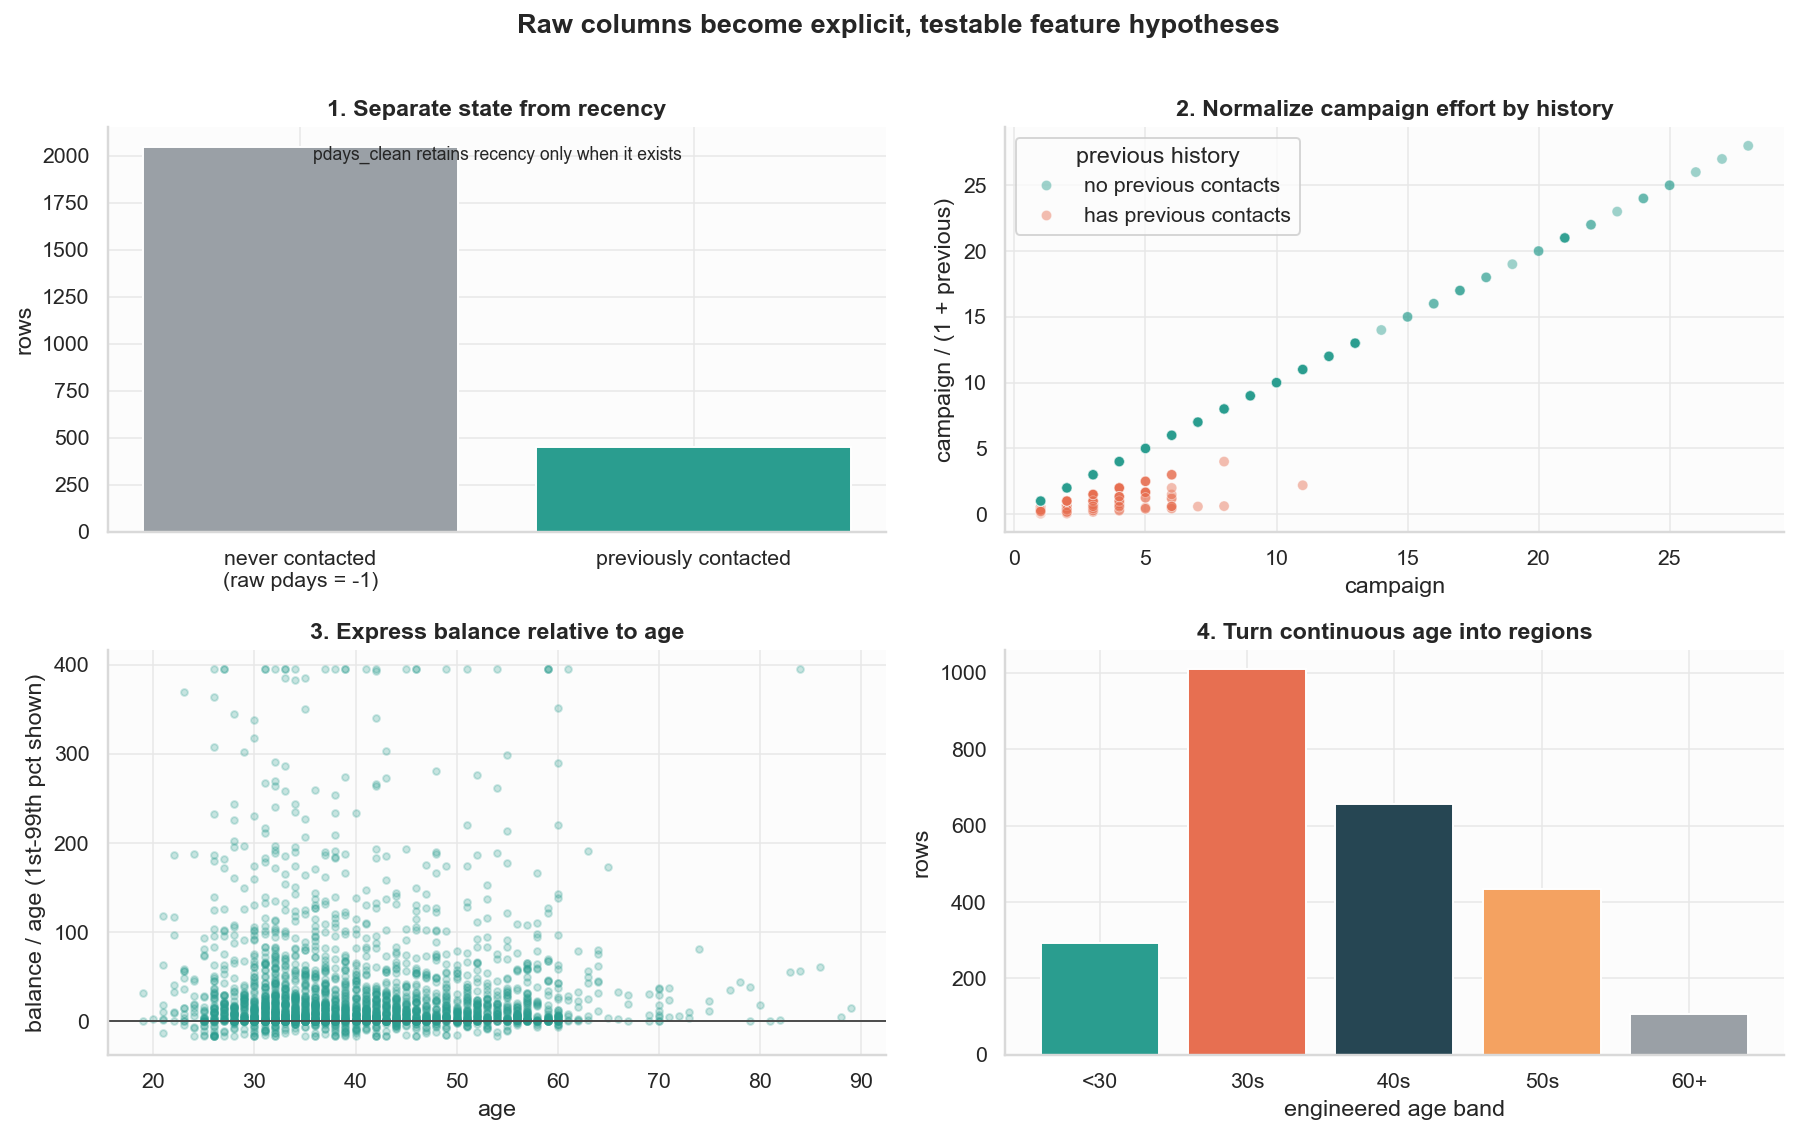

In [7]:
process_sample = X_dev.sample(min(2500, len(X_dev)), random_state=SEED)
process_features = add_domain_features(process_sample)
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=140)

contacted_counts = process_features["was_previously_contacted"].value_counts().reindex([0, 1])
axes[0, 0].bar(["never contacted\n(raw pdays = -1)", "previously contacted"],
               contacted_counts, color=["#9aa0a6", BRAND_COLOR])
axes[0, 0].set(ylabel="rows", title="1. Separate state from recency")
axes[0, 0].text(0.5, 0.92, "pdays_clean retains recency only when it exists",
                transform=axes[0, 0].transAxes, ha="center", fontsize=9)

pressure_view = process_features.loc[:, ["campaign", "previous", "contact_pressure"]].copy()
pressure_view["previous history"] = np.where(
    pressure_view["previous"].eq(0), "no previous contacts", "has previous contacts"
)
sns.scatterplot(data=pressure_view, x="campaign", y="contact_pressure",
                hue="previous history", palette=[BRAND_COLOR, ACCENT_COLOR],
                alpha=0.45, s=28, ax=axes[0, 1])
axes[0, 1].set(title="2. Normalize campaign effort by history",
               ylabel="campaign / (1 + previous)")

lower, upper = process_features["balance_per_age"].quantile([0.01, 0.99])
ratio_view = process_features["balance_per_age"].clip(lower, upper)
axes[1, 0].scatter(process_sample["age"], ratio_view, s=12, alpha=0.25,
                   color=BRAND_COLOR)
axes[1, 0].axhline(0, color="#4a4a4a", linewidth=1)
axes[1, 0].set(xlabel="age", ylabel="balance / age (1st-99th pct shown)",
               title="3. Express balance relative to age")

age_counts = process_features["age_band"].value_counts().reindex(
    ["<30", "30s", "40s", "50s", "60+"]
)
axes[1, 1].bar(
    age_counts.index, age_counts.values,
    color=sns.color_palette([BRAND_COLOR, ACCENT_COLOR, "#264653", "#f4a261", "#9aa0a6"]),
)
axes[1, 1].set(xlabel="engineered age band", ylabel="rows",
               title="4. Turn continuous age into regions")

fig.suptitle("Raw columns become explicit, testable feature hypotheses", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


`OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10)` groups categories that
are rare in each training fold and safely handles unseen validation values. It returns a sparse
matrix, which logistic regression and LightGBM can consume. Avoid forcing dense output: the
memory cost can grow rapidly with cardinality.

## Choosing interpretable classification metrics

Accuracy is easy to explain: *what fraction of predictions were correct?* But the positive
class is uncommon, so an always-negative classifier can look strong. We therefore report
accuracy as the headline metric and keep four diagnostic metrics:

- **balanced accuracy:** average recall across the positive and negative classes;
- **precision:** among predicted subscriptions, how many actually subscribed;
- **recall:** among actual subscriptions, how many the model found;
- **F1:** a compact balance of precision and recall.

These label metrics require a threshold; this notebook uses `0.5` consistently. Changing the
threshold changes all five values, so it must be chosen from business costs rather than adjusted
after viewing validation results.


In [8]:
positive_rate = y_dev.mean()
majority_accuracy = max(positive_rate, 1 - positive_rate)
print(f"positive class: {positive_rate:.1%}")
print(f"always predict 'no' accuracy: {majority_accuracy:.1%}")


positive class: 11.7%
always predict 'no' accuracy: 88.3%


## Build the preprocessing pipeline

Numeric columns are median-imputed and standardized for logistic regression. Categorical
columns are imputed, one-hot encoded, and protected against rare or unseen values. Defining the
complete preprocessor here makes the fit boundary visible: every learned statistic is fitted
only on a training fold by the enclosing pipeline.


In [9]:
def make_preprocessor(frame):
    features = frame.drop(columns=[TARGET], errors="ignore")
    categorical = features.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()
    numerical = features.select_dtypes(include=np.number).columns.tolist()

    numeric_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=10,
            sparse_output=True,
        )),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipe, numerical),
        ("categorical", categorical_pipe, categorical),
    ], sparse_threshold=0.3)


In [10]:
baseline = Pipeline([
    ("preprocess", make_preprocessor(development)),
    ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
])
engineered_frame = add_domain_features(development)
engineered = Pipeline([
    ("features", FunctionTransformer(add_domain_features, validate=False)),
    ("preprocess", make_preprocessor(engineered_frame)),
    ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
])

fold_metrics = {}

def cv_summary(name, estimator):
    scores = cross_validate(
        estimator, X_dev, y_dev, cv=CV_SPLITS,
        scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1"],
        n_jobs=-1,
    )
    fold_metrics[name] = pd.DataFrame({
        metric: scores[f"test_{metric}"]
        for metric in ["accuracy", "balanced_accuracy", "precision", "recall", "f1"]
    }).rename_axis("fold")
    accuracy = scores["test_accuracy"]
    return {
        "experiment": name,
        "accuracy_mean": accuracy.mean(),
        "accuracy_sd": accuracy.std(ddof=1),
        "accuracy_se": accuracy.std(ddof=1) / np.sqrt(len(accuracy)),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
    }

ablation = pd.DataFrame([cv_summary("raw features", baseline),
                         cv_summary("domain features", engineered)]).set_index("experiment")
ablation


,accuracy_mean,accuracy_sd,accuracy_se,balanced_accuracy,precision,recall,f1
experiment,,,,,,,
raw features,0.888083,0.000878,0.000507,0.562812,0.594400,0.138177,0.224104
domain features,0.887500,0.000661,0.000382,0.564954,0.578066,0.143875,0.230178


The standard deviation describes variation among these folds; the standard error describes
uncertainty in their mean under the fold-sampling approximation. With only 3–5 correlated
folds, neither is a formal confidence guarantee. Treat tiny accuracy differences as inconclusive and
consider operational cost as well as the point estimate.

## Ablate feature families, not individual columns

The engineered set contains three hypotheses: contact history, contact pressure, and customer
demographics. Removing one family at a time makes the comparison interpretable while keeping
all learned preprocessing inside each CV fold.


,accuracy_mean,accuracy_sd,accuracy_se,balanced_accuracy,precision,recall,f1,delta_accuracy,delta_balanced_accuracy
experiment,,,,,,,,,
without demographic,0.888000,0.000866,0.000500,0.563383,0.591724,0.139601,0.225738,0.000500,-0.001571
without contact pressure,0.887667,0.000382,0.000220,0.565666,0.580050,0.145299,0.232181,0.000167,0.000712
all engineered,0.887500,0.000661,0.000382,0.564954,0.578066,0.143875,0.230178,0.000000,0.000000
without contact history,0.887250,0.000661,0.000382,0.564194,0.573329,0.142450,0.228064,-0.000250,-0.000759


,delta_accuracy,delta_balanced_accuracy,delta_recall,delta_f1
experiment,,,,
without contact history,-0.000250,-0.000759,-0.001425,-0.002113
without contact pressure,0.000167,0.000712,0.001425,0.002004
without demographic,0.000500,-0.001571,-0.004274,-0.004440


/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/categorical.py:1200: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explic

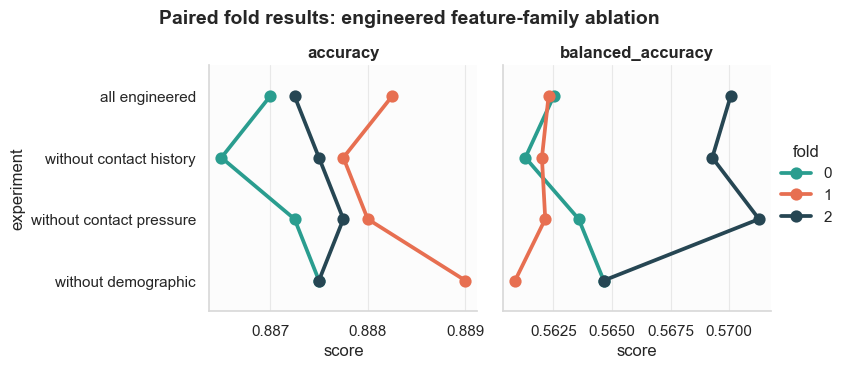

In [11]:
FEATURE_FAMILIES = {
    "contact history": ["was_previously_contacted", "pdays_clean"],
    "contact pressure": ["contact_pressure"],
    "demographic": ["balance_per_age", "age_band"],
}

def domain_features_without(frame, excluded=()):
    return add_domain_features(frame).drop(columns=list(excluded), errors="ignore")

def pipeline_without(excluded=()):
    schema = domain_features_without(development, excluded)
    transform = FunctionTransformer(
        domain_features_without, kw_args={"excluded": tuple(excluded)}, validate=False
    )
    return Pipeline([
        ("features", transform),
        ("preprocess", make_preprocessor(schema)),
        ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
    ])

family_ablation = [cv_summary("all engineered", pipeline_without())]
for family, columns in FEATURE_FAMILIES.items():
    family_ablation.append(cv_summary(f"without {family}", pipeline_without(columns)))
family_ablation = pd.DataFrame(family_ablation).set_index("experiment")
family_ablation["delta_accuracy"] = (
    family_ablation["accuracy_mean"] - family_ablation.loc["all engineered", "accuracy_mean"]
)
family_ablation["delta_balanced_accuracy"] = (
    family_ablation["balanced_accuracy"]
    - family_ablation.loc["all engineered", "balanced_accuracy"]
)
display(family_ablation.sort_values("accuracy_mean", ascending=False))

all_folds = fold_metrics["all engineered"]
paired_rows = []
for experiment in family_ablation.index.drop("all engineered"):
    difference = fold_metrics[experiment] - all_folds
    paired_rows.append({
        "experiment": experiment,
        **{f"delta_{metric}": difference[metric].mean()
           for metric in ["accuracy", "balanced_accuracy", "recall", "f1"]},
    })
paired_differences = pd.DataFrame(paired_rows).set_index("experiment")
display(paired_differences)

plot_data = pd.concat(
    {name: values[["accuracy", "balanced_accuracy"]]
     for name, values in fold_metrics.items()
     if name == "all engineered" or name.startswith("without")},
    names=["experiment", "fold"],
).reset_index().melt(
    id_vars=["experiment", "fold"], var_name="metric", value_name="score"
)
g = sns.catplot(
    data=plot_data, x="score", y="experiment", hue="fold", col="metric",
    kind="point", sharex=False, height=3.5, aspect=1.15,
    palette=[BRAND_COLOR, ACCENT_COLOR, "#264653"],
)
g.set_titles("{col_name}")
g.fig.suptitle(
    "Paired fold results: engineered feature-family ablation",
    y=1.05, fontsize=14, fontweight="bold",
)
plt.show()


## Feature validation

Feature code deserves tests. We check row preservation, finite constructed ratios, valid age
bands, and the no-current-duration contract. Production validation would also enforce allowed
categories, ranges, and data types at ingestion.


In [12]:
check = add_domain_features(X_dev)
assert len(check) == len(X_dev)
assert check.index.equals(X_dev.index)
assert "duration" not in check
assert np.isfinite(check["contact_pressure"]).all()
assert np.isfinite(check["balance_per_age"]).all()
assert check["age_band"].notna().all()
original = X_dev.head(2).copy(deep=True)
add_domain_features(original)
pd.testing.assert_frame_equal(original, X_dev.head(2))

empty = add_domain_features(X_dev.iloc[:0])
assert empty.empty and list(empty.columns) == list(check.columns)

with_null = X_dev.head(1).copy()
with_null.loc[with_null.index[0], "age"] = np.nan
null_result = add_domain_features(with_null)
assert pd.isna(null_result["balance_per_age"].iloc[0])
assert pd.isna(null_result["age_band"].iloc[0])

try:
    add_domain_features(X_dev.drop(columns="age"))
    raise AssertionError("missing-column validation did not run")
except ValueError as error:
    assert "age" in str(error)

invalid_age = X_dev.head(1).copy()
invalid_age["age"] = 0
try:
    add_domain_features(invalid_age)
    raise AssertionError("age validation did not run")
except ValueError as error:
    assert "positive" in str(error)

print("feature checks passed, including schema, null, empty, and mutation cases")


feature checks passed, including schema, null, empty, and mutation cases


## Inspect what the pipeline actually learned

Human-readable output names catch accidental omissions and category explosions. Coefficients
below are associations conditional on the other transformed inputs, not causal effects.
Because numeric inputs are standardized, their magnitudes are more comparable; one-hot
coefficients require extra care: all category indicators are retained, so there is no single
omitted reference category and correlated columns can make individual coefficients unstable.
Use them to inspect model behavior, not as unique causal effects.


In [13]:
inspection_model = engineered.fit(X_dev, y_dev)
names = inspection_model.named_steps["preprocess"].get_feature_names_out()
coefficients = pd.Series(
    inspection_model.named_steps["model"].coef_[0], index=names, name="coefficient"
)
display(pd.concat([coefficients.nsmallest(10), coefficients.nlargest(10)]).to_frame())
print(f"{len(X_dev.columns)} raw columns -> {len(names)} transformed columns")

unseen = X_val.head(1).copy()
unseen["job"] = "__NEW_JOB_AT_INFERENCE__"
transformed_unseen = inspection_model[:-1].transform(unseen)
assert transformed_unseen.shape[1] == len(names)
print("unseen category transformed safely; output shape", transformed_unseen.shape)


,coefficient
categorical__contact_unknown,-1.063268
categorical__month_jan,-1.018041
categorical__month_nov,-0.871529
categorical__poutcome_failure,-0.832912
categorical__month_aug,-0.737569
categorical__job_housemaid,-0.710218
categorical__month_jul,-0.613841
categorical__poutcome_unknown,-0.481374
numeric__campaign,-0.477397
categorical__housing_yes,-0.468155


15 raw columns -> 58 transformed columns
unseen category transformed safely; output shape (1, 58)


## Native categorical handling with CatBoost

CatBoost builds statistics for categorical values using ordered target statistics designed to
reduce target leakage. We pass raw strings and categorical column indices; we do **not** fit a
target encoder on the whole dataset. Missing values would need explicit string/category handling.
A stratified subset of development data is used for early stopping. The course validation set
remains untouched until the final comparison. Log loss is used for early stopping because it is
sensitive to probability quality even when the predicted class does not change; accuracy remains
the headline reporting metric.


refit CatBoost on all development rows with 176 trees


,accuracy,balanced_accuracy,precision,recall,f1
always no,0.88300,0.500000,0.000000,0.000000,0.000000
raw one-hot logistic,0.89000,0.573475,0.614754,0.160256,0.254237
engineered one-hot logistic,0.88925,0.570270,0.605042,0.153846,0.245315
native CatBoost,0.89450,0.588071,0.676923,0.188034,0.294314


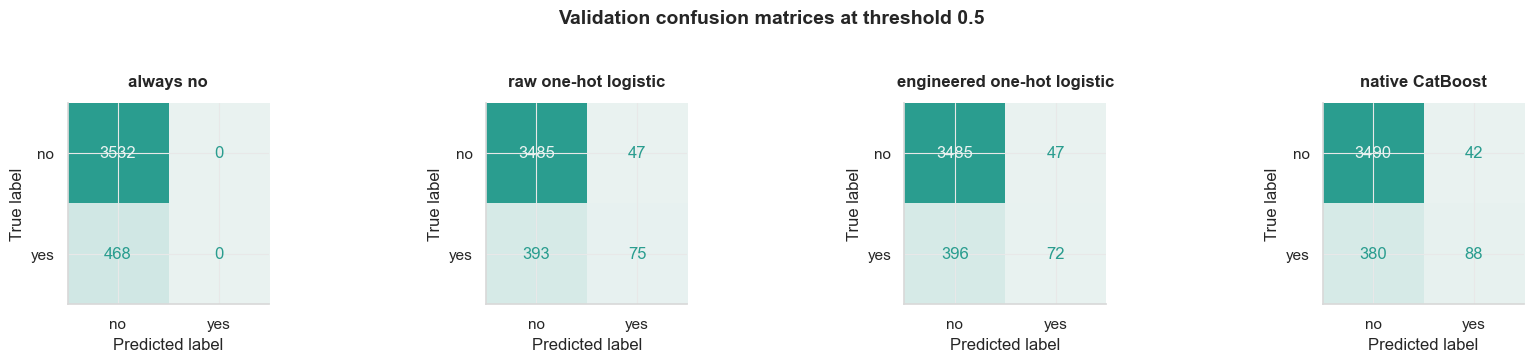

At threshold 0.5, native CatBoost has the highest balanced accuracy (0.588), with accuracy=0.894, precision=0.677, and recall=0.188.


In [14]:
from catboost import CatBoostClassifier
cat_columns = X_dev.select_dtypes(include="object").columns.tolist()
X_dev_cat, X_val_cat = X_dev.copy(), X_val.copy()
for c in cat_columns:
    X_dev_cat[c] = X_dev_cat[c].fillna("__MISSING__")
    X_val_cat[c] = X_val_cat[c].fillna("__MISSING__")

X_cat_fit, X_cat_stop, y_cat_fit, y_cat_stop = train_test_split(
    X_dev_cat, y_dev, test_size=0.15, stratify=y_dev, random_state=SEED
)

cat_stop_model = CatBoostClassifier(
    iterations=180 if FAST_MODE else 450, depth=6, learning_rate=0.06,
    loss_function="Logloss", eval_metric="Logloss", random_seed=SEED,
    verbose=False, allow_writing_files=False,
)
cat_stop_model.fit(X_cat_fit, y_cat_fit, cat_features=cat_columns,
                   eval_set=(X_cat_stop, y_cat_stop),
                   early_stopping_rounds=40, verbose=False)
best_iterations = cat_stop_model.get_best_iteration() + 1
cat_model = CatBoostClassifier(
    iterations=best_iterations, depth=6, learning_rate=0.06,
    loss_function="Logloss", random_seed=SEED,
    verbose=False, allow_writing_files=False,
)
cat_model.fit(X_dev_cat, y_dev, cat_features=cat_columns, verbose=False)
print(f"refit CatBoost on all development rows with {best_iterations} trees")

onehot_model = inspection_model
raw_onehot_model = baseline.fit(X_dev, y_dev)
def threshold_metrics(y_true, probability, threshold=0.5):
    prediction = probability >= threshold
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
    }

validation_probabilities = {
    "always no": np.zeros(len(y_val)),
    "raw one-hot logistic": raw_onehot_model.predict_proba(X_val)[:, 1],
    "engineered one-hot logistic": onehot_model.predict_proba(X_val)[:, 1],
    "native CatBoost": cat_model.predict_proba(X_val_cat)[:, 1],
}
comparison = pd.DataFrame({
    name: threshold_metrics(y_val, probability)
    for name, probability in validation_probabilities.items()
}).T
display(comparison)

fig, axes = plt.subplots(1, 4, figsize=(17, 3.5))
for axis, (name, probability) in zip(axes, validation_probabilities.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_val, probability >= 0.5, display_labels=["no", "yes"],
        colorbar=False, cmap=sns.light_palette(BRAND_COLOR, as_cmap=True), ax=axis,
    )
    axis.set_title(name, pad=12, fontweight="bold")
fig.suptitle("Validation confusion matrices at threshold 0.5", y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

best_name = comparison["balanced_accuracy"].idxmax()
print(
    f"At threshold 0.5, {best_name} has the highest balanced accuracy "
    f"({comparison.loc[best_name, 'balanced_accuracy']:.3f}), with "
    f"accuracy={comparison.loc[best_name, 'accuracy']:.3f}, "
    f"precision={comparison.loc[best_name, 'precision']:.3f}, and "
    f"recall={comparison.loc[best_name, 'recall']:.3f}."
)


Native categorical support is not automatically superior: it changes the model family as well
as the encoding. A clean encoding comparison would hold the estimator and tuning budget fixed,
which is not fully possible here. Treat this as a workflow comparison.

## What this experiment tells us

In the stored reduced-mode run, domain features do not improve overall accuracy, but they
slightly improve recall, F1, and balanced accuracy. The fold-level changes are tiny, so the
evidence is insufficient to claim that the added feature complexity is worthwhile. CatBoost
produces the strongest validation balanced accuracy and recall at threshold `0.5`, while the
confusion matrices show that every model still misses most subscribers. That is a threshold and
decision-policy question for a later lesson, not a reason to tune on this validation set here.

## Common mistakes and leakage warnings

- Computing target means or category frequencies on all rows before CV.
- Creating bins using full-data quantiles outside the pipeline.
- Treating `pdays=-1` as negative recency.
- Densifying a large sparse one-hot matrix without checking memory.
- Keeping engineered features because they sound plausible despite null ablation results.

## Exercises

1. Add cyclical month encoding and explain why chronology is still incomplete.
2. Replace fixed age bands with a spline (`SplineTransformer`) and compare it by CV.
3. Plot fold-level accuracy and balanced-accuracy changes for each feature-family ablation.
4. **Challenge:** implement a scikit-learn-compatible transformer that learns rare categories
   during `fit` and maps them during `transform`; verify it with estimator checks and an unseen category.

## Summary

Feature engineering is safe when the prediction contract is explicit, row-wise logic is pure,
and every learned transformation is fit inside CV. Ablation—not narrative plausibility—decides
whether a feature earns operational complexity.

## References

- [ColumnTransformer](https://scikit-learn.org/stable/modules/compose.html#column-transformer-for-heterogeneous-data)
- [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
- [Pipeline and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
- [Common pitfalls and recommended practices](https://scikit-learn.org/stable/common_pitfalls.html)
- [Feature engineering chapter, scikit-learn MOOC](https://inria.github.io/scikit-learn-mooc/python_scripts/03_categorical_pipeline.html)
- [CatBoost categorical features](https://catboost.ai/en/docs/features/categorical-features)
- [CatBoost training algorithm](https://catboost.ai/docs/en/concepts/algorithm-main-stages)
- [How CatBoost transforms categorical features](https://catboost.ai/docs/en/concepts/algorithm-main-stages_cat-to-numberic)
- [CatBoost paper: unbiased boosting with categorical features](https://arxiv.org/abs/1706.09516)
